# The Best Neighborhood in Pittsburgh

## Sub-Metric: Crime Activity

CMPINF 10/11 — Final Project (Notebook created by Eldar Cakolli)

---

## 1. Introduction

One of the most important factors when in pursuit of a "great" neighorhood is safety. A neighborhood can have great amenities, but if crime is high, it negatively impacts quality of life and comfort for residents. Furthermore, an instable environment increases chances of poor mental health, injury or even death. 

For my sub-metric, I am arguing that the best neighborhood in Pittsburgh is the area with the lowest amount of criminal activity. I analyze this concept by using reported incident dat, where fewer crimes indicates a safer and therefore “better” neighborhood.

Crime is a strong indicator of neighborhood stability, affecting everything from housing prices to community trust. Because of this, it is a meaningful metric when evaluating overall neighborhood quality.

My dataset spans 2024–2026, providing a recent and relevant snapshot of crime distribution across Pittsburgh neighborhoods.

---

## 2. The Metric

### Dataset

Dataset: Monthly Criminal Activity (2024–2026)  
Source: WPRDC  
Coverage: 2024–2026  

Each row represents a reported crime incident in Pittsburgh.

### Key Column Used:
- "Neighborhood" which determines the location of crime

---

### How I Calculate the Sub-Metric Score

For each neighborhood, I compute:

- "Total Crime Count" which is the number of reported incidents  
- Lower crime count = better neighborhood  

The neighborhood with the lowest crime count is considered the safest and therefore ranks highest in this sub-metric.

---

## 3. Analysis

### Setup and Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

crime = pd.read_excel("incidents_2024_thru_mar2026.xlsx")

print("Dataset shape:", crime.shape)
crime.head()

Dataset shape: (89038, 19)


,Report_Number,ReportedDate,ReportedTime,Hour,DayofWeek,ReportedMonth,NIBRS_Coded_Offense,NIBRS_Offense_Code,NIBRS_Offense_Category,NIBRS_Offense_Type,NIBRS_Crime_Against,NIBRS_Offense_Grouping,Violation,XCOORD,YCOORD,Zone,Tract,Neighborhood,Block_Address
0,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,13A AGGRAVATED ASSAULT,13A,Assault Offenses,Aggravated Assault,Person,A,18 2718 A1 Strangulation Basic - Applying,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
1,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,13C INTIMIDATION,13C,Assault Offenses,Intimidation,Person,A,18 2706 A1 Terroristic Threats-General,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
2,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,90Z ALL OTHER OFFENSES,90Z,All other Offenses,All other Offenses,Group B,B,75 3733 A Fleeing or Attempting To Elude Polic...,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
3,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,23H ALL OTHER LARCENY,23H,Larceny/Theft Offenses,All Other Larceny,Property,A,18 3921 A Theft by Unlawful Taking-Movable – L...,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
4,PGHP24000017,2024-01-01,00:21,0,Monday,Jan,9999 Vehicle Offense (Not NIBRS Reportable),999,Not NIBRS Reportable,Not NIBRS Reportable,Group B,B,LO 6 101 Discharge of Firearms Prohibited,-80.0243,40.4582,Zone 1,2107,Manchester,"1200 Block of COLUMBUS AVE Pittsburgh, PA"


### Clean Data and Criminal Count

In [2]:
crime_clean = crime[['Neighborhood']].dropna()

crime_counts = crime_clean['Neighborhood'].value_counts().reset_index()
crime_counts.columns = ['Neighborhood', 'Crime Count']
pd.set_option('display.max_rows', None)


crime_counts

,Neighborhood,Crime Count
0,Central Business District,9132
1,South Side Flats,5681
2,Carrick,2814
3,East Liberty,2437
4,Shadyside,2390
5,East Allegheny,2295
6,Knoxville,1773
7,Bloomfield,1764
8,Mount Washington,1743
9,Squirrel Hill South,1609


### Safety Based Sorting and Table

In [3]:
crime_counts = crime_counts.sort_values('Crime Count', ascending=True)
pd.set_option('display.max_rows', None)


crime_counts

,Neighborhood,Crime Count
93,Chartiers City,5
92,St. Clair,12
91,Saint Clair,25
90,Ridgemont,40
89,Chartiers,49
88,New Homestead,61
87,Swisshelm Park,76
86,East Carnegie,80
85,Summer Hill,94
84,Spring Hill-City View,103


### Visualization

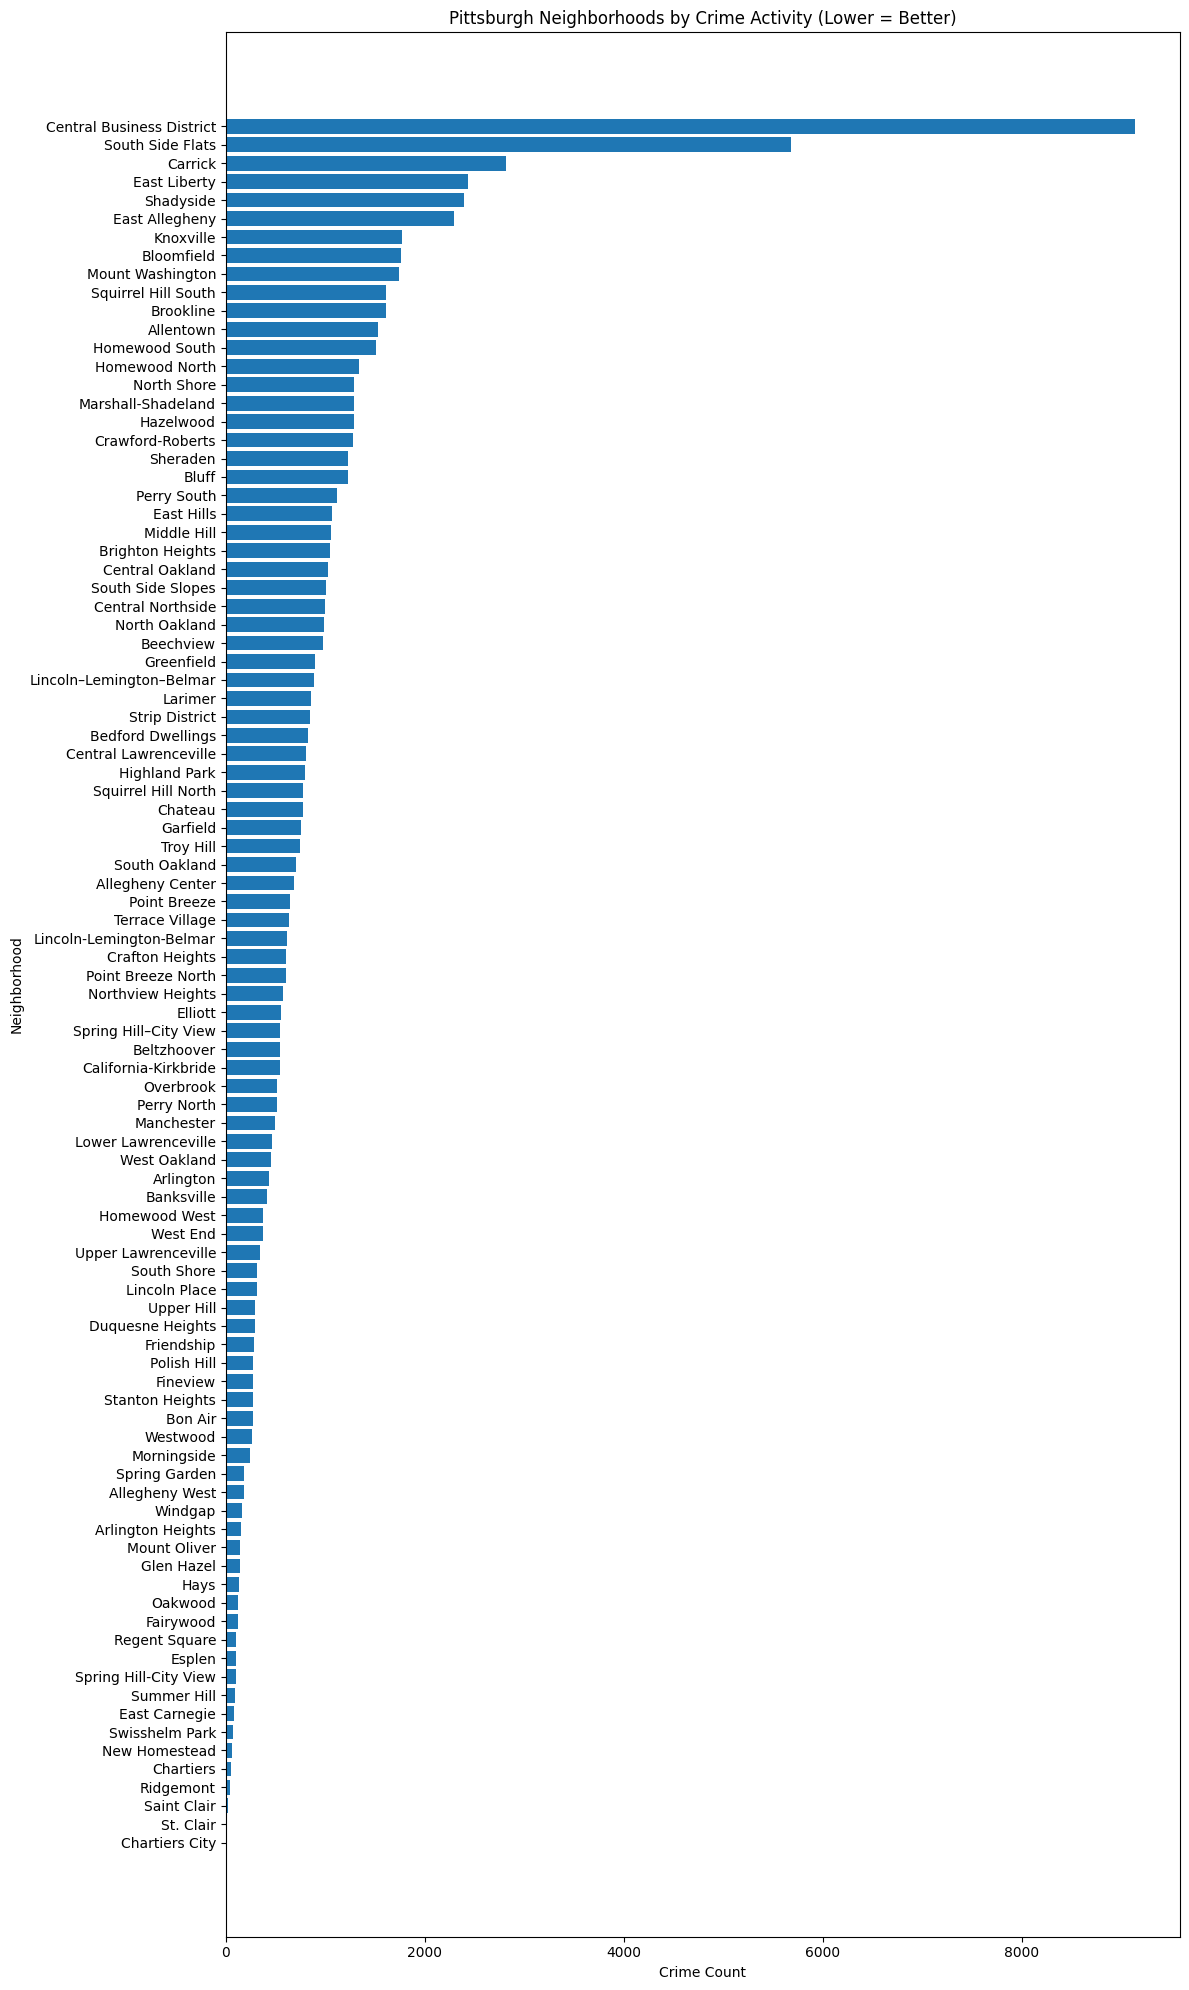

In [4]:
plt.figure(figsize=(12, 20))

plt.barh(crime_counts['Neighborhood'], crime_counts['Crime Count'])

plt.xlabel("Crime Count")
plt.ylabel("Neighborhood")
plt.title("Pittsburgh Neighborhoods by Crime Activity (Lower = Better)")

plt.tight_layout()
plt.show()

---
## 4. The Best Neighborhood — Crime Sub-Metric Result


In [5]:
best = crime_counts.iloc[0]
worst = crime_counts.iloc[-1]

print("BEST NEIGHBORHOOD (Crime):")
print(best)

print("\nWORST NEIGHBORHOOD (Crime):")
print(worst)

BEST NEIGHBORHOOD (Crime):
Neighborhood    Chartiers City
Crime Count                  5
Name: 93, dtype: object

WORST NEIGHBORHOOD (Crime):
Neighborhood    Central Business District
Crime Count                          9132
Name: 0, dtype: object


Based on monthly reported crime incidents, Chartiers City is the safest area in Pittsburgh due to the lowest reported crime count. On the other hand, the most dangerous area in Pittsburgh was Central Business District because of the highest reported crime count.  Lower crime frequency suggests better public safety, stronger community stability, and improved quality of life. The visualization above established the best and worst neighborhoods in Pittsburgh based on safety reflected by total reported incidents.

---
## 5. Sub-Metric Score (for Group Combination)

To combine with other group members’ metrics, I normalize my results into a final score of the best.

For this sub-metric:
- Lower crime = better neighborhood
- These values will be used in the final group “best neighborhood” calculation

In [6]:
# Normalize crime into a 0–100 score (higher = better safety)
crime_counts['Safety Score'] = 100 - (
    (crime_counts['Crime Count'] - crime_counts['Crime Count'].min()) /
    (crime_counts['Crime Count'].max() - crime_counts['Crime Count'].min()) * 100
)

crime_final = crime_counts.sort_values('Safety Score', ascending=False)
pd.set_option('display.max_rows', None)


crime_final

,Neighborhood,Crime Count,Safety Score
93,Chartiers City,5,100.000000
92,St. Clair,12,99.923304
91,Saint Clair,25,99.780870
90,Ridgemont,40,99.616522
89,Chartiers,49,99.517914
88,New Homestead,61,99.386436
87,Swisshelm Park,76,99.222088
86,East Carnegie,80,99.178262
85,Summer Hill,94,99.024871
84,Spring Hill-City View,103,98.926263


---
## 6. Conclusion

This analysis shows that crime levels vary significantly across Pittsburgh neighborhoods. Some neighborhoods consistently report far fewer incidents, making them stronger candidates for the “best neighborhood” classification, while other areas report far higher incidents, removing them from the classification of "best." From this metric of data, Chartiers City was established as the "best" neighborhood due to its high safety score, while Central Business District was the "worst" neighborhood due to its "poor" safety score. 

The results did not shock me because the unstable environment of areas such as Central Business District or South Side Flats is extremely noticeable. Equally, the environment of areas such as Chartiers City is noticeable safe and peaceful. However, I am upset to read how unsafe the Central Business District is since it is one of my favorite areas in Pittsburgh due to its' beautiful architecture.

--- 